In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Step 1: Load the Data

In [21]:
df_master = pd.read_csv(r"/Users/arindamdasbiswas/Documents/python_mini_project/Customer_Master_Data.csv")
df_txn = pd.read_csv(r"/Users/arindamdasbiswas/Documents/python_mini_project/Customer_Transactions.csv")


In [22]:
#Check Shape
print("Transactions Shape:", df_txn.shape)
print("Master Shape:", df_master.shape)


Transactions Shape: (23050, 3)
Master Shape: (1000, 9)


In [23]:
##Preview Data Master
print("\Master Data:")
df_master.head()

\Master Data:


,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
1,CUST10001,Divit Kohli,mkalita@sarin.com,Female,48,Kolkata,Married,0,2023-12-06
2,CUST10002,Kiara Behl,apteanay@hotmail.com,Male,75,Kolkata,Widowed,2,2023-08-23
3,CUST10003,Vaibhav Sankar,bseshadri@choudhry.info,Male,62,Pune,Divorced,2,2022-11-17
4,CUST10004,Shray D’Alia,bdhillon@toor-mall.com,Male,55,Delhi,Divorced,0,2022-12-04


In [24]:
##Preview Data transaction
print("\nTransactions Data:")
df_txn.head()



Transactions Data:


,CustomerID,TransactionDate,TransactionAmount
0,CUST10771,7/31/23,2383.07
1,CUST10100,3/10/24,497.54
2,CUST10031,2/17/25,536.78
3,CUST10987,7/17/23,314.89
4,CUST10831,12/15/24,2543.19


In [25]:
##Check Data Types & Info
print("\nTransactions Info:")
print(df_txn.info())

print("\nMaster Info:")
print(df_master.info())



Transactions Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23050 entries, 0 to 23049
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         23050 non-null  object 
 1   TransactionDate    23050 non-null  object 
 2   TransactionAmount  23050 non-null  float64
dtypes: float64(1), object(2)
memory usage: 540.4+ KB
None

Master Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1000 non-null   object
 1   Name           1000 non-null   object
 2   Email          1000 non-null   object
 3   Gender         1000 non-null   object
 4   Age            1000 non-null   int64 
 5   City           1000 non-null   object
 6   MaritalStatus  1000 non-null   object
 7   NumChildren    1000 non-null   int64 
 8   JoinDate       1000

# Step 2: Clean the Data

In [63]:
#########Data Cleaning
####Convert Date Columns
# Convert to datetime
df_txn['TransactionDate'] = pd.to_datetime(
    df_txn['TransactionDate'],
    errors='coerce'
)

df_master['JoinDate'] = pd.to_datetime(
    df_master['JoinDate'],
    errors='coerce'
)


In [27]:
####Check Null Values
print("\nNull Values in Transactions:")
print(df_txn.isnull().sum())

print("\nNull Values in Master:")
print(df_master.isnull().sum())



Null Values in Transactions:
CustomerID           0
TransactionDate      0
TransactionAmount    0
dtype: int64

Null Values in Master:
CustomerID       0
Name             0
Email            0
Gender           0
Age              0
City             0
MaritalStatus    0
NumChildren      0
JoinDate         0
dtype: int64


In [28]:
####Handle Null Values (if any)

# Drop rows with null dates
df_txn = df_txn.dropna(subset=['TransactionDate'])
df_master = df_master.dropna(subset=['JoinDate'])

# Fill numeric nulls (if any)
df_txn['TransactionAmount'] = df_txn['TransactionAmount'].fillna(0)


In [29]:
df_master.head()

,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
1,CUST10001,Divit Kohli,mkalita@sarin.com,Female,48,Kolkata,Married,0,2023-12-06
2,CUST10002,Kiara Behl,apteanay@hotmail.com,Male,75,Kolkata,Widowed,2,2023-08-23
3,CUST10003,Vaibhav Sankar,bseshadri@choudhry.info,Male,62,Pune,Divorced,2,2022-11-17
4,CUST10004,Shray D’Alia,bdhillon@toor-mall.com,Male,55,Delhi,Divorced,0,2022-12-04


In [30]:
df_txn.head()

,CustomerID,TransactionDate,TransactionAmount
0,CUST10771,2023-07-31,2383.07
1,CUST10100,2024-03-10,497.54
2,CUST10031,2025-02-17,536.78
3,CUST10987,2023-07-17,314.89
4,CUST10831,2024-12-15,2543.19


In [31]:
### Validate Data Types
# Ensure correct types
df_txn['TransactionAmount'] = df_txn['TransactionAmount'].astype(float)

In [32]:
####Check Duplicate CustomerID in Master

# Check duplicates
duplicates = df_master['CustomerID'].duplicated().sum()

print("Duplicate CustomerIDs in Master:", duplicates)



Duplicate CustomerIDs in Master: 0


In [33]:
###Ensure CustomerID Exists in Master

# Find missing CustomerIDs
missing_customers = set(df_txn['CustomerID']) - set(df_master['CustomerID'])

print("Missing CustomerIDs in Transactions:", len(missing_customers))


Missing CustomerIDs in Transactions: 0


In [34]:
## Filter Invalid Transactions 
# Keep only valid CustomerIDs
df_txn = df_txn[
    df_txn['CustomerID'].isin(df_master['CustomerID'])
]


In [37]:
##########Final Clean Data Check

print("\nFinal Transactions Shape:", df_txn.shape)
print("Final Master Shape:", df_master.shape)

df_txn.head()


Final Transactions Shape: (23050, 3)
Final Master Shape: (1000, 9)


,CustomerID,TransactionDate,TransactionAmount
0,CUST10771,2023-07-31,2383.07
1,CUST10100,2024-03-10,497.54
2,CUST10031,2025-02-17,536.78
3,CUST10987,2023-07-17,314.89
4,CUST10831,2024-12-15,2543.19


# Step 3: Merge if Needed

In [38]:
#### Merge Customer + Transactions Data

merged_df = pd.merge(
    df_txn,
    df_master,
    on='CustomerID',
    how='left'
)

print("Merged Shape:", merged_df.shape)


Merged Shape: (23050, 11)


In [39]:
# Check for missing master data after merge
missing_info = merged_df.isnull().sum()

print("\nMissing Values After Merge:")
print(missing_info)


Missing Values After Merge:
CustomerID           0
TransactionDate      0
TransactionAmount    0
Name                 0
Email                0
Gender               0
Age                  0
City                 0
MaritalStatus        0
NumChildren          0
JoinDate             0
dtype: int64


In [40]:
#####Validate Merge
# Ensure no unexpected row loss
print("Transactions Rows:", df_txn.shape[0])
print("Merged Rows:", merged_df.shape[0])


Transactions Rows: 23050
Merged Rows: 23050


In [41]:
merged_df.head()

,CustomerID,TransactionDate,TransactionAmount,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10771,2023-07-31,2383.07,Lakshay Dhillon,dharmajantara@gmail.com,Female,27,Ahmedabad,Widowed,3,2023-05-31
1,CUST10100,2024-03-10,497.54,Aniruddh Borah,jivikabhavsar@gmail.com,Female,53,Lucknow,Divorced,4,2022-01-08
2,CUST10031,2025-02-17,536.78,Ritvik Ahuja,jhaverifarhan@chandra.org,Male,40,Ahmedabad,Single,0,2023-12-03
3,CUST10987,2023-07-17,314.89,Jayan Wagle,ojas82@gmail.com,Not Disclosed,75,Bangalore,Widowed,4,2022-03-18
4,CUST10831,2024-12-15,2543.19,Ishita Agarwal,vbalay@yahoo.com,Not Disclosed,27,Jaipur,Divorced,4,2021-06-30


# Step 4: Perform RFM Calculation

In [42]:
#############Perform RFM Calculation

# Reference date (important for Recency calculation)

reference_date = df_txn['TransactionDate'].max() + pd.Timedelta(days=1)

print("Reference Date:", reference_date)


Reference Date: 2025-07-30 00:00:00


In [43]:
###Calculate Recency, Frequency, Monetary
df_rfm = df_txn.groupby('CustomerID').agg(
    Recency=('TransactionDate', lambda x: (reference_date - x.max()).days),
    Frequency=('TransactionDate', 'count'),
    Monetary=('TransactionAmount', 'sum')
).reset_index()

In [44]:
df_rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,CUST10000,13,23,21265.49
1,CUST10001,35,30,28654.31
2,CUST10002,18,24,23884.03
3,CUST10003,81,25,24206.03
4,CUST10004,8,19,25565.30


In [45]:
print("Total Customers:", df_rfm.shape[0])
print(df_rfm.describe())


Total Customers: 1000
           Recency    Frequency     Monetary
count  1000.000000  1000.000000   1000.00000
mean     50.794000    23.050000  23053.19966
std      58.124418     4.810472   5622.44101
min       1.000000     6.000000   5052.69000
25%      13.000000    20.000000  18965.46250
50%      32.000000    23.000000  22969.82000
75%      69.000000    26.000000  26827.39250
max     524.000000    38.000000  44784.99000


# Step 5 and 6: Score RFM & Create Combined RFM Segment


In [46]:
df_rfm['R_Score'] = pd.qcut(
    df_rfm['Recency'],
    5,
    labels=[5, 4, 3, 2, 1]   # reverse scoring
)

df_rfm['F_Score'] = pd.qcut(
    df_rfm['Frequency'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
)

df_rfm['M_Score'] = pd.qcut(
    df_rfm['Monetary'],
    5,
    labels=[1, 2, 3, 4, 5]
)

df_rfm['R_Score'] = pd.qcut(df_rfm['Recency'], 5, labels=[5,4,3,2,1], duplicates='drop')
df_rfm['F_Score'] = pd.qcut(df_rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5], duplicates='drop')
df_rfm['M_Score'] = pd.qcut(df_rfm['Monetary'], 5, labels=[1,2,3,4,5], duplicates='drop')

df_rfm['R_Score'] = df_rfm['R_Score'].astype(str)
df_rfm['F_Score'] = df_rfm['F_Score'].astype(str)
df_rfm['M_Score'] = df_rfm['M_Score'].astype(str)

df_rfm['RFM_Segment'] = (
    df_rfm['R_Score'] +
    df_rfm['F_Score'] +
    df_rfm['M_Score']
)

df_rfm.head()


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment
0,CUST10000,13,23,21265.49,4,3,2,432
1,CUST10001,35,30,28654.31,3,5,5,355
2,CUST10002,18,24,23884.03,4,3,3,433
3,CUST10003,81,25,24206.03,1,4,3,143
4,CUST10004,8,19,25565.30,5,1,4,514


In [47]:
df_rfm['RFM_Score'] = (
    df_rfm[['R_Score','F_Score','M_Score']]
    .astype(int)
    .sum(axis=1)
)


In [48]:
df_rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score
0,CUST10000,13,23,21265.49,4,3,2,432,9
1,CUST10001,35,30,28654.31,3,5,5,355,13
2,CUST10002,18,24,23884.03,4,3,3,433,10
3,CUST10003,81,25,24206.03,1,4,3,143,8
4,CUST10004,8,19,25565.30,5,1,4,514,10


# Step 7: Assign Segment Labels

In [50]:
##########Assign Segment Labels
df_rfm['R_Score'] = df_rfm['R_Score'].astype(int)
df_rfm['F_Score'] = df_rfm['F_Score'].astype(int)
df_rfm['M_Score'] = df_rfm['M_Score'].astype(int)


In [52]:
########Define Segment Rules (Business Logic)
def segment_customer(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    
    if r == 5 and f == 5 and m == 5:
        return "Champions"
    
    elif r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    
    elif f >= 4 and r >= 2:
        return "Loyal Customers"
    
    elif r >= 4 and f >= 2 and f <= 3:
        return "Potential Loyalist"
    
    elif m >= 4 and f >= 2 and f <= 3:
        return "Big Spenders"
    
    elif r <= 2 and f >= 3:
        return "At Risk"
    
    elif r == 1 and f <= 2 and m <= 2:
        return "Lost"
    
    else:
        return "Others"
    
df_rfm['Segment'] = df_rfm.apply(segment_customer, axis=1)


In [53]:
print(df_rfm[['CustomerID', 'RFM_Segment', 'Segment']].head())

  CustomerID RFM_Segment             Segment
0  CUST10000         432  Potential Loyalist
1  CUST10001         355     Loyal Customers
2  CUST10002         433  Potential Loyalist
3  CUST10003         143             At Risk
4  CUST10004         514              Others


In [54]:
print(df_rfm['Segment'].value_counts())

Segment
Others                251
Loyal Customers       206
Potential Loyalist    167
Champions             131
At Risk               120
Lost                   73
Big Spenders           52
Name: count, dtype: int64


# Step 8: Visualize



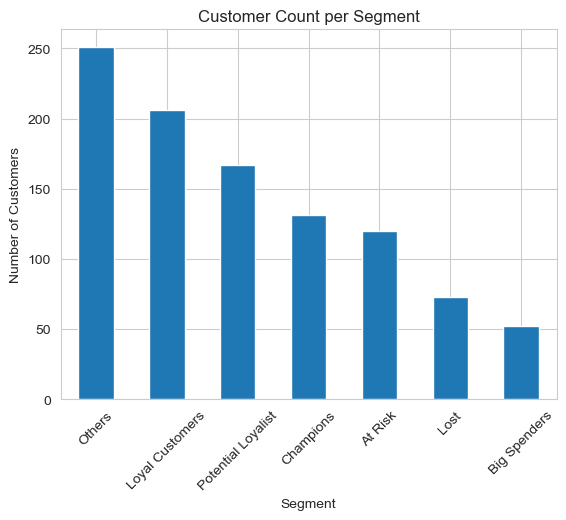

In [55]:
#########Count of Customers per Segment

segment_counts = df_rfm['Segment'].value_counts()

plt.figure()
segment_counts.plot(kind='bar')
plt.title("Customer Count per Segment")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()


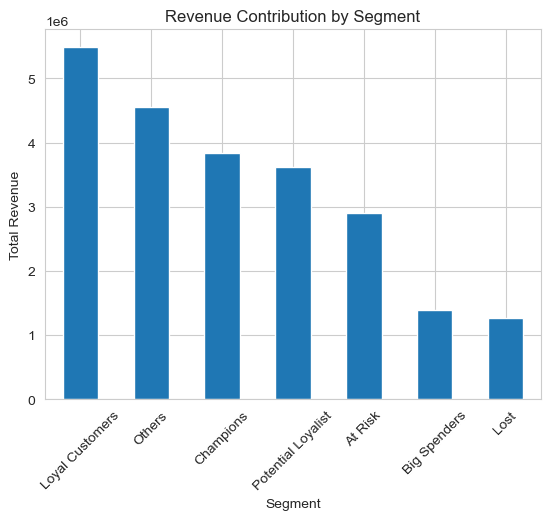

In [58]:
########Revenue Contribution per Segment

revenue_segment = df_rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

plt.figure()
revenue_segment.plot(kind='bar')
plt.title("Revenue Contribution by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()


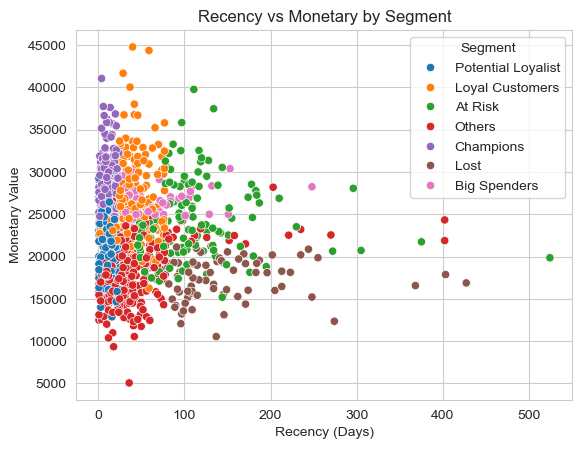

In [59]:
#######Recency vs Monetary (Scatter Plot)
plt.figure()
sns.scatterplot(
    data=df_rfm,
    x='Recency',
    y='Monetary',
    hue='Segment'
)

plt.title("Recency vs Monetary by Segment")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value")
plt.show()


In [57]:
### Pareto Analysis (80/20 Rule)
pareto_df = df_rfm.sort_values(by='Monetary', ascending=False)

pareto_df['Cumulative_Revenue'] = pareto_df['Monetary'].cumsum()
pareto_df['Cumulative_Percentage'] = (
    pareto_df['Cumulative_Revenue'] / pareto_df['Monetary'].sum()
) * 100



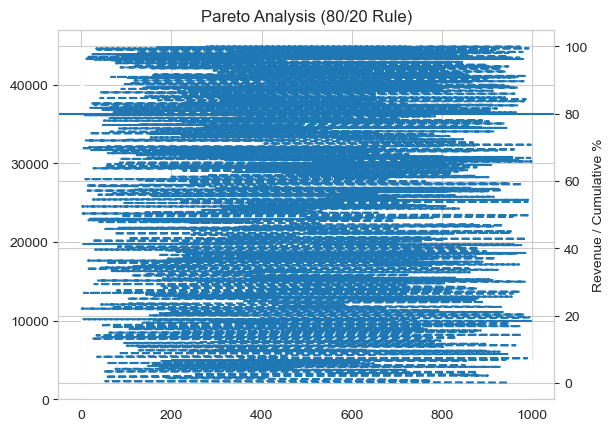

In [60]:
######Plot Pareto Chart

plt.figure()

# Bar plot (Revenue)
plt.bar(range(len(pareto_df)), pareto_df['Monetary'])

# Line plot (Cumulative %)
plt.twinx()
plt.plot(pareto_df['Cumulative_Percentage'], linestyle='--')

plt.axhline(80)  # 80% line

plt.title("Pareto Analysis (80/20 Rule)")
plt.xlabel("Customers (sorted)")
plt.ylabel("Revenue / Cumulative %")

plt.show()


In [118]:
###Check Top 20% Contribution
top_20_percent = int(0.2 * len(pareto_df))

top_revenue = pareto_df.head(top_20_percent)['Monetary'].sum()
total_revenue = pareto_df['Monetary'].sum()

print("Top 20% Revenue Contribution:", round((top_revenue / total_revenue) * 100, 2), "%")


Top 20% Revenue Contribution: 27.03 %


# Full Dashboard 

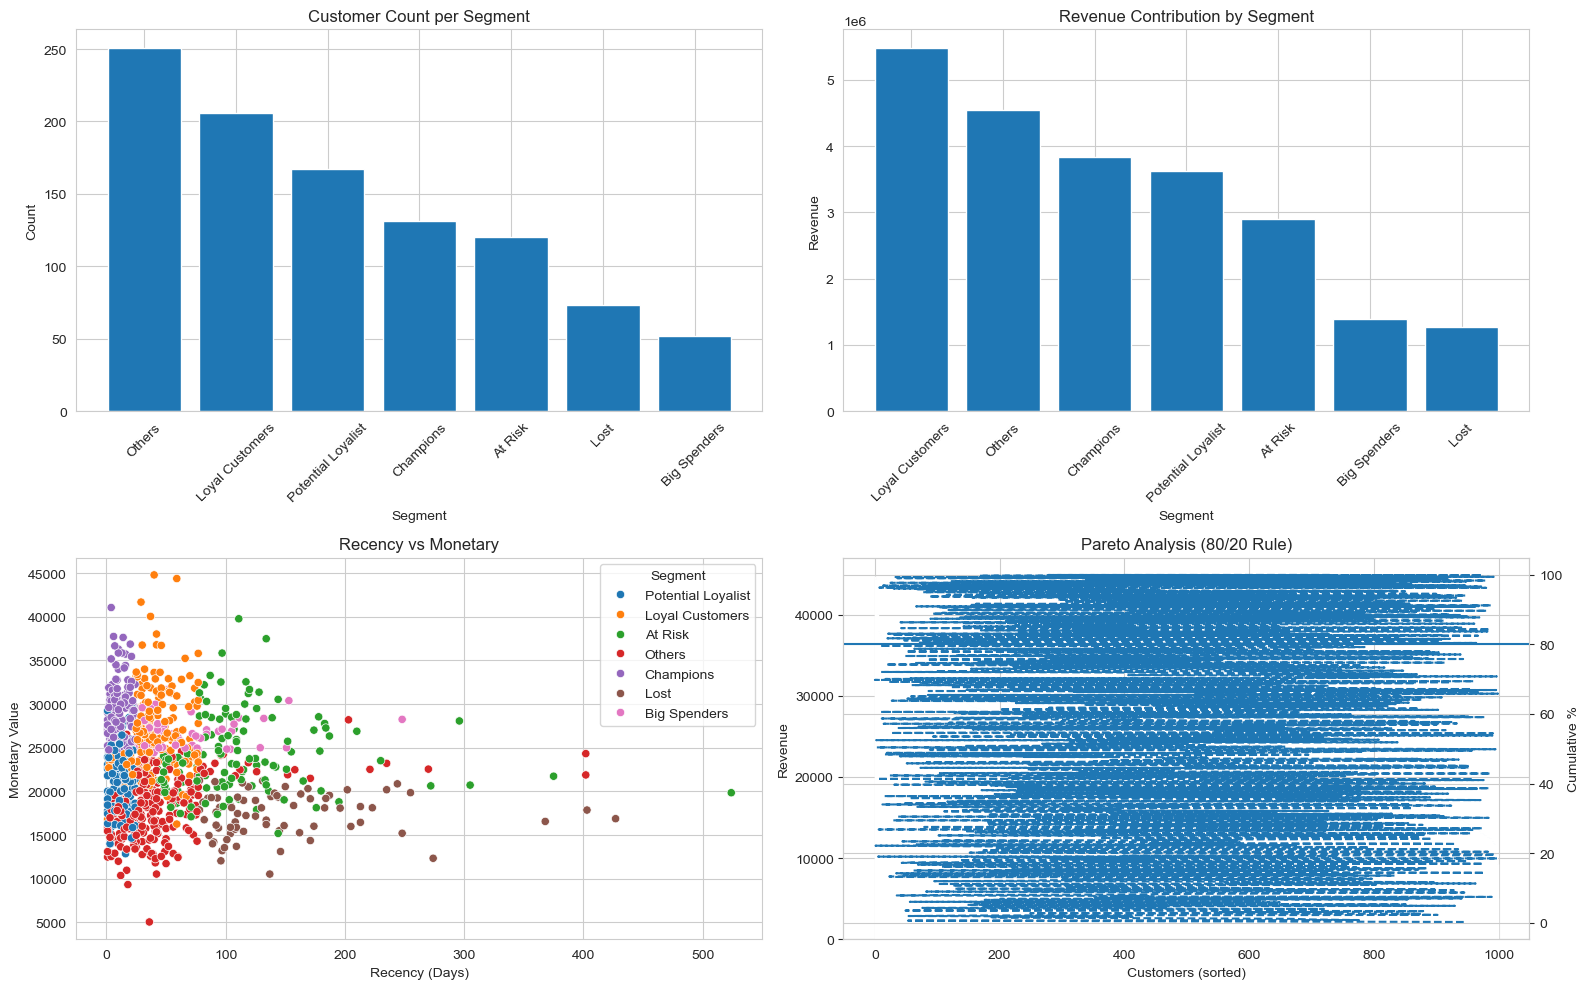

In [61]:

# --- Prepare Data ---

# Segment Count
segment_counts = df_rfm['Segment'].value_counts()

# Revenue by Segment
revenue_segment = df_rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

# Pareto Data
pareto_df = df_rfm.sort_values(by='Monetary', ascending=False)
pareto_df['Cumulative_Revenue'] = pareto_df['Monetary'].cumsum()
pareto_df['Cumulative_Percentage'] = (
    pareto_df['Cumulative_Revenue'] / pareto_df['Monetary'].sum()
) * 100


# --- Create Subplots ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Customer Count per Segment
axes[0, 0].bar(segment_counts.index, segment_counts.values)
axes[0, 0].set_title("Customer Count per Segment")
axes[0, 0].set_xlabel("Segment")
axes[0, 0].set_ylabel("Count")
axes[0, 0].tick_params(axis='x', rotation=45)


#  2. Revenue per Segment
axes[0, 1].bar(revenue_segment.index, revenue_segment.values)
axes[0, 1].set_title("Revenue Contribution by Segment")
axes[0, 1].set_xlabel("Segment")
axes[0, 1].set_ylabel("Revenue")
axes[0, 1].tick_params(axis='x', rotation=45)


# 3. Recency vs Monetary Scatter
sns.scatterplot(
    data=df_rfm,
    x='Recency',
    y='Monetary',
    hue='Segment',
    ax=axes[1, 0]
)
axes[1, 0].set_title("Recency vs Monetary")
axes[1, 0].set_xlabel("Recency (Days)")
axes[1, 0].set_ylabel("Monetary Value")


# 4. Pareto Chart
axes[1, 1].bar(range(len(pareto_df)), pareto_df['Monetary'])
ax2 = axes[1, 1].twinx()
ax2.plot(pareto_df['Cumulative_Percentage'], linestyle='--')

ax2.axhline(80)

axes[1, 1].set_title("Pareto Analysis (80/20 Rule)")
axes[1, 1].set_xlabel("Customers (sorted)")
axes[1, 1].set_ylabel("Revenue")
ax2.set_ylabel("Cumulative %")


# --- Layout Fix ---
plt.tight_layout()
plt.show()

# Insights 

In [62]:
##Insights
## 1) Revenue Concentration: A small group of customers (Champions & Loyal) contributes the majority of revenue, aligning with the Pareto principle (80/20 rule).
## 2) Customer Behavior: Customers with recent activity and high spend are the most valuable, while those with high recency and low spend are disengaging.
## 3) Retention Opportunity: At-risk customers were previously valuable and can be reactivated through targeted campaigns.
## 4) Growth Potential: New and average customers present an opportunity to increase lifetime value through engagement and upselling.
## 5) Business Focus: Prioritize retention of high-value customers, re-engage at-risk segments, and nurture new customers into loyal ones.

# Champions & Loyal Customers drive the majority of revenue → prioritize retention
# Potential Loyalists are growth opportunities → nurture early
# At Risk customers need re-engagement campaigns
# Lost customers have low ROI → minimal focus
# Big Spenders should be targeted with premium offerings
